# Quantum Y Factor



![](quantum-y-factor-cartoon.png)

In [1]:
import json
import serial.tools.list_ports
from windfreak import SynthHD
import time
import pyvisa
from RsInstrument import RsInstrument, BinFloatFormat
import skrf as rf
import matplotlib.pyplot as plt
import numpy as np
from urllib.request import urlopen
from pathlib import Path
import os
import sys
from datetime import datetime
import matplotlib.colors as mcolors

In [2]:
rm = pyvisa.ResourceManager()
instruments = rm.list_resources()
for instrument in instruments:
    print(instrument)

USB0::0x03EB::0x2065::YOKOGAWA_GS210_91U322681_2.02::INSTR
USB0::0x03EB::0x2065::Rohde_Schwarz_ZVA24-2Port_1145111024100131_3.30::INSTR
USB0::0x03EB::0x2065::Agilent_Technologies_33220A_MY44053372_2.07-2.06-2::INSTR
USB0::0x03EB::0x2065::Hewlett-Packard__E7405A__SG45102671__A.14.04::INSTR
ASRL3::INSTR
ASRL4::INSTR


In [3]:
ports = serial.tools.list_ports.comports()
for port in ports:
    #print(f"Port Name:   {port.device}")
    #print(f"Description: {port.description}")
    #print(f"Hardware ID: {port.hwid}")  # Shows USB Vendor ID, Product ID, and Location string
    #print("-" * 30)
    if 'A3E5' in port.hwid:
        print(f"Windfreak is on COM port {port.device}")

synth = SynthHD("COM4")
synth.init()

rf_probe = synth[0]
rf_probe.enable = False
rf_probe.frequency = 5.5e9   # set Channel A frequency
rf_probe.power = -30        # set Channel A power

rf_pump = synth[1]
rf_pump.enable = False
rf_pump.frequency = 8e9   # frequency in Hz
rf_pump.power = 0        #  power in dBm

Windfreak is on COM port COM4


In [4]:
noise_source_bias = None
for instrument in instruments:
    if '33220A' in instrument:
        # Initialize instrument
        noise_source_bias = rm.open_resource(instrument) 
        break
print("noise source bias:" + noise_source_bias.query('*IDN?').strip())

vna = None
for instrument in instruments:
    if 'Rohde' in instrument:
        # Initialize instrument
        vna = RsInstrument(instrument, id_query=True, reset=False) 
        break

print("vna:" + vna.query('*IDN?').strip())

spa = None
for instrument in instruments:
    if '7405' in instrument:
        spa = rm.open_resource(instrument) 
        break

print("spa:" + spa.query('*IDN?').strip())

noise_diode_bias = None
for instrument in instruments:
    if 'YOKOGAWA' in instrument:
        # Initialize instrument
        noise_diode_bias = rm.open_resource(instrument) 
        break

print("noise_diode_bias:" + noise_diode_bias.query('*IDN?').strip())

WARM_SWITCHES_IP_ADDRESS = '169.254.12.12'
PROGRAMMABLE_ATTENUATOR_IP_ADDRESS = '169.254.11.11'

def send_url_command(ip_address, cmd_to_send):
    url = f"http://{ip_address}/:{cmd_to_send}"
    for attempt in range(3):
        try:
            with urlopen(url, timeout=3) as response:
                pte_return = response.read()
            if len(pte_return) > 100:
                print(f"Error, command not found: {url}")
                return "Invalid Command!"
            return pte_return.decode('utf-8').strip()
        except Exception as network_err:
            if attempt == 2:
                print(f"Hardware Network Warning: No response from {ip_address}. Error: {network_err}")
                return "No Response!"
            time.sleep(0.05)
            
def set_warm_switches_by_ip(ip_address, A, B, C, D):
    state_byte = 128 + int(A-1) + (2 * int(B-1)) + (4 * int(C-1)) + (8 * int(D-1))
    return send_url_command(ip_address, f"SETP={state_byte}")

def set_programmable_attenuator(attenuation):
    send_url_command(PROGRAMMABLE_ATTENUATOR_IP_ADDRESS, f"SETATT={attenuation}")

def get_switch_state(ip_address):
    raw_reply = send_url_command(ip_address, "SWPORT?")
    if any(err in raw_reply for err in ["Error", "No Response"]):
        return {"status": "Disconnected or Error", "raw_reply": raw_reply}
    try:
        state_byte = int(raw_reply.strip())
        working_value = state_byte - 128
        return {
            "status": "Online",
            "raw_byte": state_byte,
            "A": working_value % 2 + 1,
            "B": (working_value // 2) % 2 + 1,
            "C": (working_value // 4) % 2 + 1,
            "D": (working_value // 8) % 16 + 1
        }
    except ValueError:
        return {"status": f"Malformed hardware response: {raw_reply}"}

def get_attenuator_state(ip_address):
    # The direct URL that successfully delivers the information
    url = f"http://{ip_address}/ATT?"
    
    try:
        with urlopen(url, timeout=2.0) as response:
            # Read bytes, decode to string, and remove whitespace/newlines
            attenuation_value = response.read().decode('utf-8').strip()
            return float(attenuation_value)
            
    except URLError as e:
        print(f"Connection failed: {e.reason}")
        return None
    except ValueError:
        print(f"Parsing Error: Could not convert response to number: {attenuation_value}")
        return None
vna.go_to_local()

noise source bias:Agilent Technologies,33220A,MY44053372,2.07-2.06-22-2
vna:Rohde&Schwarz,ZVA24-2Port,1145111024100131,3.30
spa:Hewlett-Packard, E7405A, SG45102671, A.14.04
noise_diode_bias:YOKOGAWA,GS210,91U322681,2.02


In [22]:
get_switch_state(WARM_SWITCHES_IP_ADDRESS)
# A does nothing
# B 1 is vna and 2 is spa
# C 1 is fridge 2 is noise diode
# D 1 is vna 2 is to synthesizer A channel (rf_probe)

# set_warm_switches_by_ip(WARM_SWITCHES_IP_ADDRESS, 1, 1, 1, 1) # vna --> fridge --> vna
# set_warm_switches_by_ip(WARM_SWITCHES_IP_ADDRESS, 1, 2, 1, 1) # vna --> fridge --> spa
# set_warm_switches_by_ip(WARM_SWITCHES_IP_ADDRESS, 1, 2, 2, 1) # noise_diode --> spa
# set_warm_switches_by_ip(WARM_SWITCHES_IP_ADDRESS, 1, 2, 1, 2) # synth --> fridge --> spa



{'status': 'Online', 'raw_byte': 130, 'A': 1, 'B': 2, 'C': 1, 'D': 1}

In [7]:
noise_diode_bias.query('*IDN?')

'YOKOGAWA,GS210,91U322681,2.02\n'

In [8]:
noise_diode_bias.query(':OUTPUT?')

'0\n'

In [9]:
print(noise_diode_bias.query(":SOURce:RANGe?").strip())

30E+0


In [10]:
noise_diode_bias.write(":SOURce:FUNCtion VOLTage")
noise_diode_bias.write(":SOURce:RANGe 30")
noise_diode_bias.write(":SOURce:LEVel 28.0")


20

In [11]:
vna.write("OUTPut:STATe OFF")
print(int(vna.query("OUTPut:STATe?")))
vna.go_to_local()

0


In [33]:
f0 = 5.58e9
B = 1e6
spa.write(':DET:FUNC SAMP')
spa.write(':BAND:VID 1000')
spa.write(':BAND ' + str(B))
spa.write(':FREQ:CENT ' + str(f0))
spa.write(':FREQ:SPAN 0')


14

In [18]:
planck_constant = 6.62607015e-34 # J s
spa_state = {}

spa_state['vbw'] = float(spa.query(':SENS:BAND:VID?').strip())
print("vbw:" + str(spa_state['vbw']))
spa_state['rbw'] = float(spa.query(':SENS:BAND?').strip())
print("rbw:" + str(spa_state['rbw']))
spa_state['f0'] = float(spa.query('SENSe:FREQuency:CENTer?').strip())
print("f0:" + str(spa_state['f0']))
spa_state['ref_level'] = float(spa.query(':DISPlay:WINDow:TRACe:Y:SCALe:RLEVel?').strip())
spa_state['unit'] = spa.query(':UNIT:POWer?').strip()

print("ref level:" + str(spa_state['ref_level'])  + " "+ spa_state['unit'])

p = 0.0
while True:
    try:
        spa.write("INIT:IMM")
        spa.query("*OPC?")
        trace = np.array(spa.query_ascii_values("TRAC? TRACE1"))
        if np.isnan(trace).any():
            raise ValueError
        p = np.mean(trace)
        sigma_p = np.std(trace)
        break
    except (pyvisa.errors.VisaIOError, ValueError):
        spa.clear()
        time.sleep(0.1)
time.sleep(0.05)
print("p = " + str(p) + " W")
gamma = p/(f0*planck_constant)
print("gamma = " + str(gamma) + " photons/s")

vbw:1000.0
rbw:1000000.0
f0:5580000000.0
ref level:5e-09 W
p = 9.885530024937655e-10 W
gamma = 267368186992715.84 photons/s


In [39]:

# vna power and hot wire bias off: 
set_warm_switches_by_ip(WARM_SWITCHES_IP_ADDRESS, 1, 2, 1, 1) # vna --> fridge --> spa
vna.write("OUTPut:STATe OFF")
noise_source_bias.write(':OUTP OFF')
p_all_off = 0.0

while True:
    try:
        spa.write("INIT:IMM")
        spa.query("*OPC?")
        trace = np.array(spa.query_ascii_values("TRAC? TRACE1"))
        if np.isnan(trace).any():
            raise ValueError
        p_all_off = np.mean(trace)
        p_all_off_sigma = np.std(trace)
        break
    except (pyvisa.errors.VisaIOError, ValueError):
        spa.clear()
        time.sleep(0.1)
time.sleep(0.05)
print("p_all_off = " + str(p_all_off) + " W")

noise_source_bias.write(':OUTP ON')
p_hot_wire_on = 0.0
while True:
    try:
        spa.write("INIT:IMM")
        spa.query("*OPC?")
        trace = np.array(spa.query_ascii_values("TRAC? TRACE1"))
        if np.isnan(trace).any():
            raise ValueError
        p_hot_wire_on = np.mean(trace)
        p_hot_wire_on_sigma = np.std(trace)
        break
    except (pyvisa.errors.VisaIOError, ValueError):
        spa.clear()
        time.sleep(0.1)
time.sleep(0.05)
noise_source_bias.write(':OUTP OFF')
print("p_hot_wire_on = " + str(p_hot_wire_on) + " W")

vna_power = -35
vna.write('SOURce1:POWer ' +  str(vna_power))
vna.write('SENSe1:FREQuency:CW ' + str(f0) + ' HZ')
vna.write("OUTPut:STATe ON")
p_vna_on = 0.0
while True:
    try:
        spa.write("INIT:IMM")
        spa.query("*OPC?")
        trace = np.array(spa.query_ascii_values("TRAC? TRACE1"))
        if np.isnan(trace).any():
            raise ValueError
        p_vna_on = np.mean(trace)
        p_vna_on_sigma = np.std(trace)
        break
    except (pyvisa.errors.VisaIOError, ValueError):
        spa.clear()
        time.sleep(0.1)
time.sleep(0.05)
print("p_vna_on = " + str(p_vna_on) + " W")



p_all_off = 9.131760249376557e-10 W
p_hot_wire_on = 1.1702509975062344e-09 W
p_vna_on = 1.0091742069825436e-09 W


In [52]:
set_warm_switches_by_ip(WARM_SWITCHES_IP_ADDRESS, 1, 2, 1, 1) # vna --> fridge --> spa
noise_source_bias.write(':OUTP OFF')

vna_power_dbm_start = -35
vna_power_dbm_stop = -28
vna_power_dbm_number_of_points = 51
vna_power_dbm_array = np.linspace(vna_power_dbm_start, vna_power_dbm_stop, vna_power_dbm_number_of_points)

p_vna_power_sweep = []
for vna_power_dbm in vna_power_dbm_array:
    print(vna_power_dbm)
    vna.write('SOURce1:POWer ' +  str(vna_power_dbm))
    while True:
        try:
            spa.write("INIT:IMM")
            spa.query("*OPC?")
            trace = np.array(spa.query_ascii_values("TRAC? TRACE1"))
            if np.isnan(trace).any():
                raise ValueError
            break
        except (pyvisa.errors.VisaIOError, ValueError):
            spa.clear()
            time.sleep(0.1)
    p_vna_power_sweep.append(np.mean(trace))        
    time.sleep(0.05)

-35.0
-34.86
-34.72
-34.58
-34.44
-34.3
-34.16
-34.02
-33.88
-33.74
-33.6
-33.46
-33.32
-33.18
-33.04
-32.9
-32.76
-32.62
-32.48
-32.34
-32.2
-32.06
-31.92
-31.78
-31.64
-31.5
-31.36
-31.22
-31.08
-30.939999999999998
-30.8
-30.66
-30.52
-30.38
-30.24
-30.1
-29.96
-29.82
-29.68
-29.54
-29.4
-29.259999999999998
-29.119999999999997
-28.98
-28.84
-28.7
-28.56
-28.419999999999998
-28.28
-28.14
-28.0


Text(0, 0.5, 'Detected Noise Power [nW]')

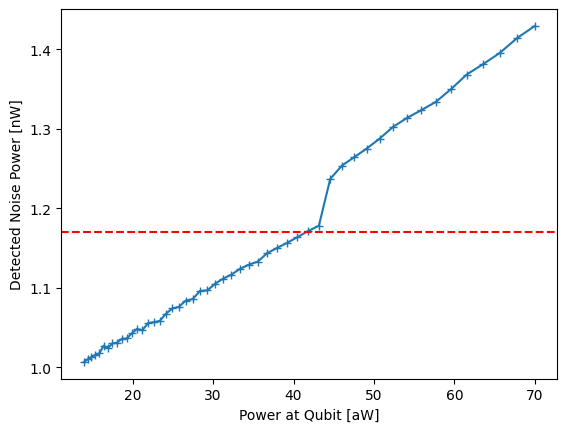

In [59]:
A = 103.55 # dB
vna_power_watts_array = 10**((vna_power_dbm_array - 103.55)/10)*1e-3

plt.plot(vna_power_watts_array/1e-18,np.array(p_vna_power_sweep)/1e-9,"+-")
plt.axhline(y=p_hot_wire_on/1e-9, color='r', linestyle='--')
plt.xlabel("Power at Qubit [aW]")
plt.ylabel("Detected Noise Power [nW]")


In [34]:
noise_source_bias.query(':OUTP?')

'0\n'

In [21]:
np.std(trace)

np.float64(2.3417054405282147e-11)

In [21]:
print(float(spa.query(':SENS:BAND?').strip()))

1000000.0


In [12]:
float(spa.query('SENSe:FREQuency:CENTer?').strip())

5580000000.0

In [14]:
float(spa.query(':DISPlay:WINDow:TRACe:Y:SCALe:RLEVel?').strip())

5e-09

In [16]:
spa.query(':UNIT:POWer?').strip()

'W'

In [26]:
spa.write(':DET:FUNC SAMP')

16

In [30]:
spa.write(':FREQ:SPAN 0')
spa.query(':FREQ:SPAN?')


'+0.00000000000E+000\n'

In [29]:
synth.close()